# Facial Recognition System using FaceNet Architecture
**Objective:** Build an end-to-end facial recognition system using a simplified FaceNet-inspired CNN with Triplet Loss for face verification (1:1) and identification (1:N).

**Parts Covered:**
1. Face Detection (OpenCV DNN)
2. Simplified FaceNet Model (128-D embeddings)
3. Triplet Loss Training
4. LFW Dataset — Real Triplet Generation
5. Face Verification (1:1)
6. Group Photo Recognition + Emotion Detection
7. t-SNE Embedding Visualization

**Tools:** Python, TensorFlow/Keras, OpenCV, Scikit-learn, DeepFace

## Step 1: Install & Import Libraries

In [ ]:

 !pip install tensorflow opencv-python scikit-learn matplotlib tqdm deepface

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import TSNE
from collections import Counter
import urllib.request
import os

print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:00
TensorFlow version: 2.19.0
All libraries imported successfully!


## Step 2: Face Detection using OpenCV DNN

I use OpenCV's built-in Deep Learning face detector (SSD + ResNet10).  


In [ ]:
# -------------------------------------------------------------------
# Download OpenCV's Deep Learning Face Detector (one-time)
# -------------------------------------------------------------------
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "deploy.prototxt"
model_path    = "res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    print("Downloading prototxt...")
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(model_path):
    print("Downloading caffemodel (23 MB)...")
    urllib.request.urlretrieve(model_url, model_path)

dnn_net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
print("OpenCV DNN Face Detector loaded!")

# -------------------------------------------------------------------
# Face Detection Function
# -------------------------------------------------------------------
def detect_faces_dnn(image_rgb, confidence_threshold=0.5):
    """Detect faces using OpenCV DNN. Returns list of (x, y, w, h)."""
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(image_rgb, (300, 300)), 1.0,
        (300, 300), (104.0, 177.0, 123.0)
    )
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []
    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            startX, startY, endX, endY = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX,   endY   = min(w, endX),   min(h, endY)
            boxes.append((startX, startY, endX - startX, endY - startY))
    return boxes

print("detect_faces_dnn() ready!")

OpenCV DNN Face Detector loaded!
detect_faces_dnn() ready!


## Step 3: Build Simplified FaceNet Model

**Architecture:**
- Input: 160 × 160 × 3
- 4 Conv Blocks (Conv2D → BatchNorm → MaxPool)
- GlobalAveragePooling → Dropout(0.5) → Dense(128)
- **L2 Normalization** → 128-D unit embedding

The L2 norm ensures all embeddings lie on a unit hypersphere, so Euclidean distance = angular difference.

In [ ]:
# -------------------------------------------------------------------
# Simplified FaceNet Model
# -------------------------------------------------------------------
def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    """Lightweight FaceNet-inspired CNN.
    Outputs L2-normalized 128-D face embeddings.
    """
    inputs = keras.Input(shape=input_shape)

    # Block 1: large kernel for initial feature extraction
    x = layers.Conv2D(64,  (5, 5), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 4
    x = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Embedding + L2 Normalization
    x = layers.Dense(embedding_size, activation=None)(x)
    embeddings = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        name='l2_normalize'
    )(x)

    return keras.Model(inputs, embeddings, name='Custom_FaceNet')

base_model = build_custom_facenet()
base_model.summary()

Model: "Custom_FaceNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 80, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (Lambda)           │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,623,552 (6.19 MB)

 Trainable params: 1,621,632 (6.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Step 4: Triplet Loss

**Formula:** `L = max(||f(A) - f(P)||² - ||f(A) - f(N)||² + margin, 0)`

- **Anchor (A):** Image of person X  
- **Positive (P):** Another image of same person X  
- **Negative (N):** Image of a different person Y  
- **margin:** Minimum separation enforced between positive and negative pairs (typically 0.2–0.5)

In [ ]:
# -------------------------------------------------------------------
# Triplet Loss Function
# -------------------------------------------------------------------
def triplet_loss(margin=0.5):
    """
    Custom Keras Triplet Loss.
    y_pred shape: (batch, 384) = concat of [anchor(128), positive(128), negative(128)]
    """
    def loss(_, y_pred):
        anchor   = y_pred[:, 0:128]
        positive = y_pred[:, 128:256]
        negative = y_pred[:, 256:384]

        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

        basic_loss = pos_dist - neg_dist + margin
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))

    return loss

print("Triplet loss defined with margin=0.5")
print("Goal: d(A,P) + 0.5 < d(A,N)  →  pull same-person pairs closer")

Triplet loss defined with margin=0.5
Goal: d(A,P) + 0.5 < d(A,N)  →  pull same-person pairs closer


## Step 5: Build Siamese (Triplet) Training Network

In [ ]:
# -------------------------------------------------------------------
# Triplet Network: 3 inputs, shared FaceNet weights
# -------------------------------------------------------------------
input_a = keras.Input(shape=(160, 160, 3), name='anchor')
input_p = keras.Input(shape=(160, 160, 3), name='positive')
input_n = keras.Input(shape=(160, 160, 3), name='negative')

# Shared weights across all three branches
emb_a = base_model(input_a)
emb_p = base_model(input_p)
emb_n = base_model(input_n)

# Concatenate to shape (batch, 384)
merged = layers.Concatenate(name='triplet_concat')([emb_a, emb_p, emb_n])

siamese_model = keras.Model(
    inputs=[input_a, input_p, input_n],
    outputs=merged,
    name='Siamese_Triplet_Net'
)
siamese_model.compile(optimizer='adam', loss=triplet_loss(margin=0.5))

print("Siamese triplet network compiled!")
print("Architecture: 3x FaceNet (shared weights) → concat → triplet loss")

Siamese triplet network compiled!
Architecture: 3x FaceNet (shared weights) → concat → triplet loss


## Step 6: Load LFW Dataset & Generate Real Triplets

**LFW (Labeled Faces in the Wild)** — a classic benchmark for face verification.  
Downloaded automatically via scikit-learn. No manual setup needed!

In [ ]:
# -------------------------------------------------------------------
# Load LFW Dataset
# -------------------------------------------------------------------
print("Downloading Labeled Faces in the Wild (LFW)...")


lfw = fetch_lfw_people(min_faces_per_person=2, color=True)

images       = lfw.images
labels       = lfw.target
target_names = lfw.target_names

print(f"\nDataset loaded!")
print(f"  Total images : {len(images)}")
print(f"  Unique people: {len(target_names)}")
print(f"  Image shape  : {images[0].shape}")
print(f"  Sample names : {list(target_names[:5])}")


Dataset loaded!
  Total images : 9164
  Unique people: 1680
  Image shape  : (62, 47, 3)
  Sample names : [np.str_('Aaron Peirsol'), np.str_('Aaron Sorkin'), np.str_('Abdel Nasser Assidi'), np.str_('Abdoulaye Wade'), np.str_('Abdullah')]


Preprocessed shape : (9164, 160, 160, 3)
Pixel range        : [0.00, 1.00]


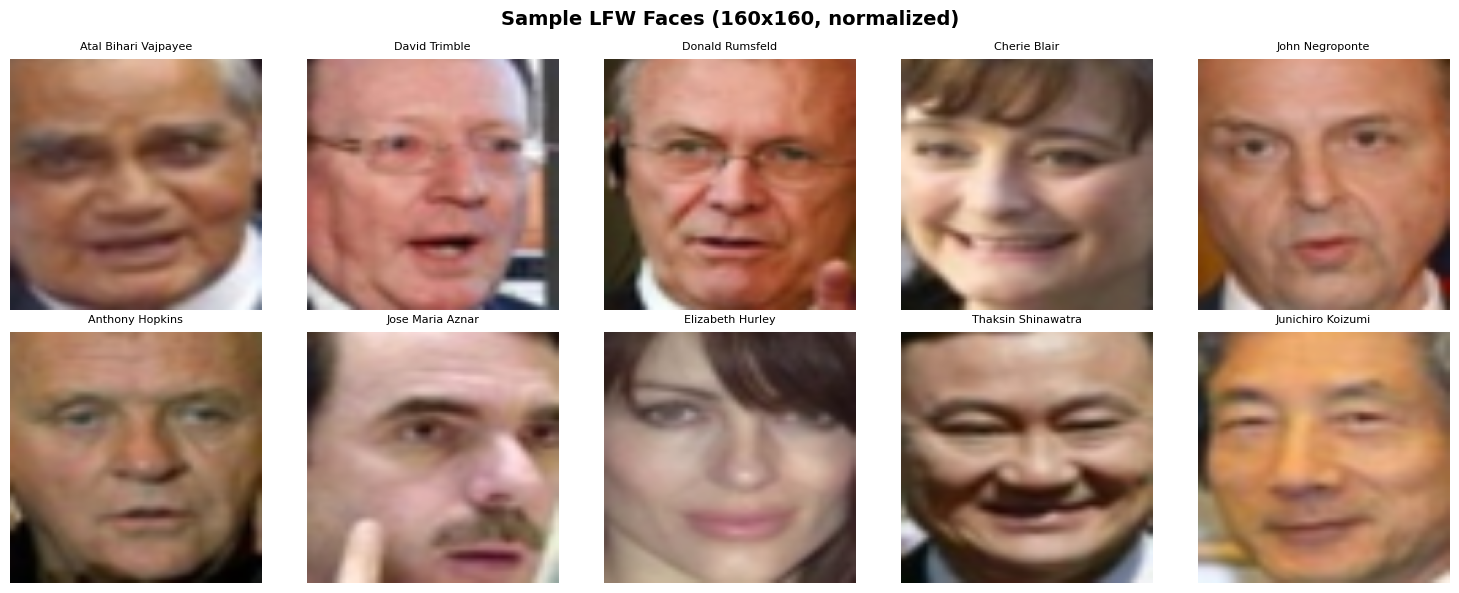

In [ ]:
# -------------------------------------------------------------------
# Preprocess: Resize to 160x160 and normalize to [0, 1]
# -------------------------------------------------------------------
def preprocess_dataset(imgs):
    processed = []
    for img in imgs:
        resized = cv2.resize(img, (160, 160))
        if resized.max() > 1.0:
            resized = resized / 255.0
        processed.append(resized)
    return np.array(processed, dtype='float32')

X_data = preprocess_dataset(images)
print(f"Preprocessed shape : {X_data.shape}")
print(f"Pixel range        : [{X_data.min():.2f}, {X_data.max():.2f}]")

# Visualize 10 sample faces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample LFW Faces (160x160, normalized)", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_data[i])
    ax.set_title(target_names[labels[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------
# Generate Real Triplets (Offline Strategy)
# -------------------------------------------------------------------
def generate_real_triplets(X, y, num_triplets=500):
    """
    Offline triplet mining:
      - Anchor & Positive = two different images of the SAME person
      - Negative          = image of a DIFFERENT person
    """
    anchors, positives, negatives = [], [], []
    unique_classes = np.unique(y)

    for _ in range(num_triplets):
        pos_class = np.random.choice(unique_classes)
        pos_indices = np.where(y == pos_class)[0]

        if len(pos_indices) < 2:
            continue

        a_idx, p_idx = np.random.choice(pos_indices, 2, replace=False)
        neg_class = np.random.choice(np.setdiff1d(unique_classes, [pos_class]))
        n_idx = np.random.choice(np.where(y == neg_class)[0])

        anchors.append(X[a_idx])
        positives.append(X[p_idx])
        negatives.append(X[n_idx])

    print(f"Generated {len(anchors)} valid triplets")
    return [np.array(anchors), np.array(positives), np.array(negatives)]

print("Creating training triplets from LFW...")
real_triplets = generate_real_triplets(X_data, labels, num_triplets=500)
print(f"Anchor shape: {real_triplets[0].shape}")

Creating training triplets from LFW...
Generated 500 valid triplets
Anchor shape: (500, 160, 160, 3)


## Step 7: Train the Model

Training Siamese Network on LFW Dataset...
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - loss: 0.4887
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - loss: 0.4376
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - loss: 0.4247
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - loss: 0.4296
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - loss: 0.4309
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - loss: 0.3945
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - loss: 0.3840
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - loss: 0.3823
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - loss: 0.3865
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - loss: 0.3670

Training Complete!


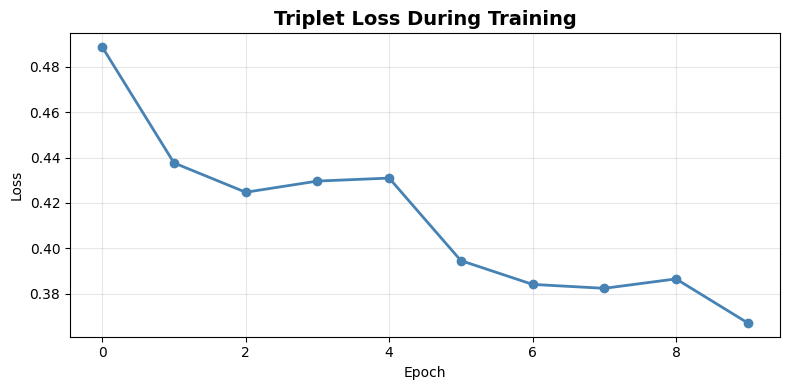

Final loss: 0.3670


In [ ]:
# -------------------------------------------------------------------
# Train Siamese Network
# -------------------------------------------------------------------
print("Training Siamese Network on LFW Dataset...")
print("="*50)

history = siamese_model.fit(
    x=real_triplets,
    y=np.zeros(len(real_triplets[0])),   # Dummy labels (loss is internal)
    epochs=10,
    batch_size=16,
    verbose=1
)

print("\nTraining Complete!")

# Plot Training Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], marker='o', color='steelblue', linewidth=2)
plt.title('Triplet Loss During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {history.history['loss'][-1]:.4f}")

## Step 8: Face Verification (1:1)

Given two face images, verify if they belong to the **same person** using cosine distance.  
- Distance < threshold → **MATCH**  
- Distance ≥ threshold → **NO MATCH**

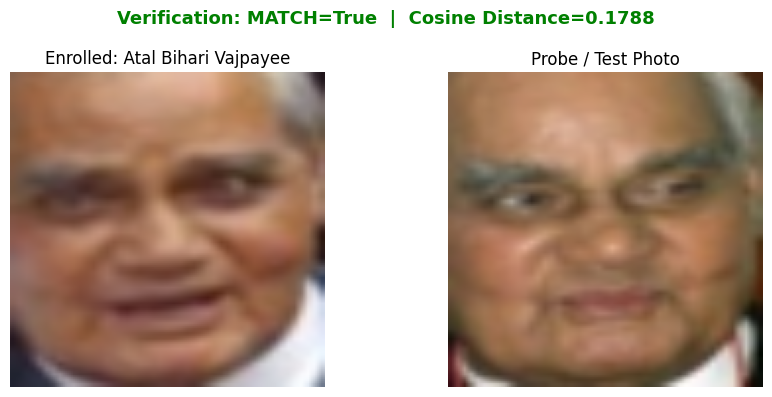

Person      : Atal Bihari Vajpayee
Distance    : 0.1788
Threshold   : 0.5
Verdict     : SAME PERSON


In [ ]:
# -------------------------------------------------------------------
# 1:1 Face Verification Test
# -------------------------------------------------------------------
test_person_id   = labels[0]
test_person_name = target_names[test_person_id]

person_indices = np.where(labels == test_person_id)[0]

img1 = X_data[person_indices[0]]  # Enrolled image
img2 = X_data[person_indices[1]]  # Test/probe image

# Extract 128-D embeddings
emb1 = base_model.predict(np.expand_dims(img1, 0), verbose=0)[0]
emb2 = base_model.predict(np.expand_dims(img2, 0), verbose=0)[0]

# Cosine distance
distance  = cosine_distances([emb1], [emb2])[0][0]
threshold = 0.5
is_match  = distance < threshold

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle(
    f"Verification: MATCH={is_match}  |  Cosine Distance={distance:.4f}",
    color="green" if is_match else "red",
    fontsize=13, fontweight='bold'
)
axes[0].imshow(img1)
axes[0].set_title(f"Enrolled: {test_person_name}")
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].set_title("Probe / Test Photo")
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Person      : {test_person_name}")
print(f"Distance    : {distance:.4f}")
print(f"Threshold   : {threshold}")
print(f"Verdict     : {'SAME PERSON' if is_match else 'DIFFERENT PERSON'}")

## Step 9: Face Identification (1:N) + Emotion Detection

Identify faces in a group photo by comparing against a registered database.  
Also uses **DeepFace** to measure happiness for each detected face.

In [ ]:
# Install DeepFace (for emotion detection)
!pip install deepface

try:
    from deepface import DeepFace
    DEEPFACE_AVAILABLE = True
    print("DeepFace loaded — emotion detection enabled!")
except ImportError:
    DEEPFACE_AVAILABLE = False
    print("DeepFace not available. Emotion detection disabled.")

26-03-27 05:26:58 - Directory /root/.deepface has been created
26-03-27 05:26:58 - Directory /root/.deepface/weights has been created
DeepFace loaded — emotion detection enabled!


In [ ]:
# -------------------------------------------------------------------
# Face Database Registration
# -------------------------------------------------------------------
known_database = {}

def register_user(name, image_path):
    """Register a person by extracting and storing their face embedding."""
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    boxes = detect_faces_dnn(img_rgb)

    if not boxes:
        print(f"No face detected in {image_path}")
        return

    x, y, w, h = boxes[0]
    margin = int(min(w, h) * 0.1)
    x1 = max(0, x - margin);  y1 = max(0, y - margin)
    x2 = min(img_rgb.shape[1], x + w + margin)
    y2 = min(img_rgb.shape[0], y + h + margin)

    face_crop      = img_rgb[y1:y2, x1:x2]
    face_resized   = cv2.resize(face_crop, (160, 160))
    face_normalized = face_resized.astype('float32') / 255.0

    emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]
    known_database[name] = emb
    print(f"Registered: {name}")

# --- Register your people here ---
# register_user("Alice", "alice.jpg")
# register_user("Bob",   "bob.jpg")
print("Database ready! Use register_user(name, image_path) to add people.")

Database ready! Use register_user(name, image_path) to add people.


Note: known_database is empty — all faces will show as 'Unknown'
      Use register_user(name, image_path) to add known people.

Image loaded: 1280x853 pixels
  DNN: 63 | Haar: 20 → using DNN
Found 63 face(s). Processing...



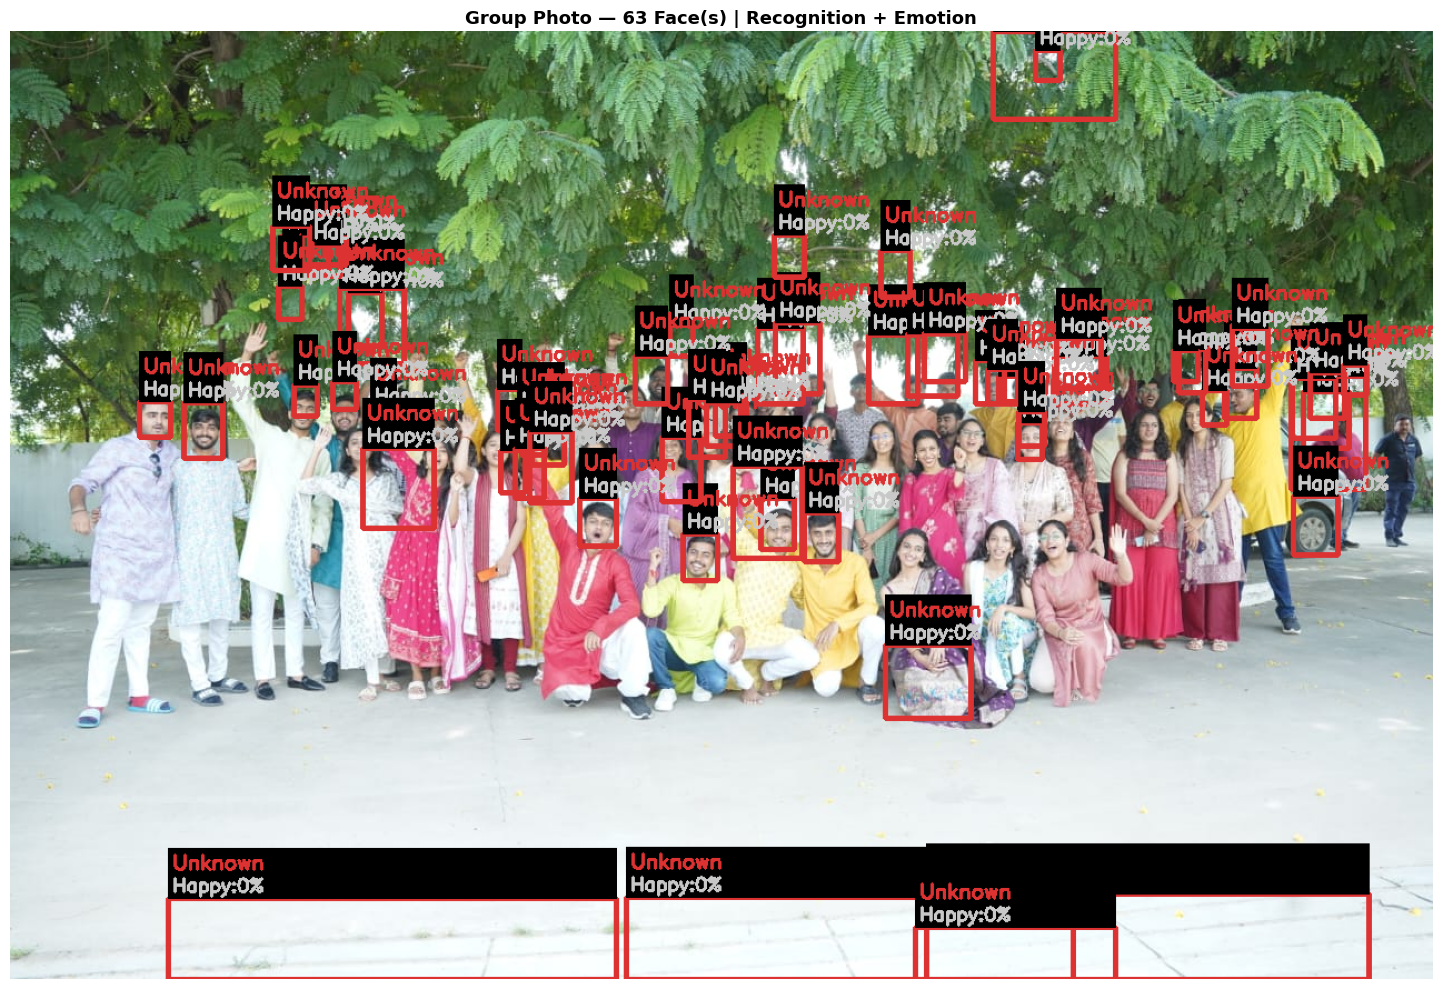


#    Identity             Dist   Happy%  Emotion     
-----------------------------------------------------------------
1    Unknown               N/A     0.0%  N/A         
2    Unknown               N/A     0.0%  N/A         
3    Unknown               N/A     0.0%  N/A         
4    Unknown               N/A     0.0%  N/A         
5    Unknown               N/A     0.0%  N/A         
6    Unknown               N/A     0.0%  N/A         
7    Unknown               N/A     0.0%  N/A         
8    Unknown               N/A     0.0%  N/A         
9    Unknown               N/A     0.0%  N/A         
10   Unknown               N/A     0.0%  N/A         
11   Unknown               N/A     0.0%  N/A         
12   Unknown               N/A     0.0%  N/A         
13   Unknown               N/A     0.0%  N/A         
14   Unknown               N/A     0.0%  N/A         
15   Unknown               N/A     0.0%  N/A         
16   Unknown               N/A     0.0%  N/A         
17   Unknown   

In [ ]:
# -------------------------------------------------------------------
# Group Photo Recognition + Happiness Detection (FIXED - Self Contained)
# -------------------------------------------------------------------

# Fix 1: Initialize known_database if not already defined
if 'known_database' not in dir():
    known_database = {}
    print("Note: known_database is empty — all faces will show as 'Unknown'")
    print("      Use register_user(name, image_path) to add known people.\n")

# Haar Cascade fallback detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_faces_dnn_fixed(image_rgb, confidence_threshold=0.1):
    """DNN face detector with lower threshold + 600x600 blob."""
    h, w = image_rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(image_rgb, (600, 600)), 1.0,
        (600, 600), (104.0, 177.0, 123.0)
    )
    dnn_net.setInput(blob)
    detections = dnn_net.forward()
    boxes = []
    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > confidence_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            startX, startY, endX, endY = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX,   endY   = min(w, endX),   min(h, endY)
            bw, bh = endX - startX, endY - startY
            if bw > 20 and bh > 20:
                boxes.append((startX, startY, bw, bh))
    return boxes


def detect_faces_combined(image_rgb, confidence_threshold=0.1):
    """DNN first, Haar fallback if DNN finds fewer faces."""
    dnn_boxes = detect_faces_dnn_fixed(image_rgb, confidence_threshold)

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    haar_raw = face_cascade.detectMultiScale(
        gray, scaleFactor=1.05, minNeighbors=3, minSize=(30, 30)
    )
    haar_boxes = [tuple(b) for b in haar_raw] if len(haar_raw) > 0 else []

    if len(haar_boxes) > len(dnn_boxes):
        print(f"  DNN: {len(dnn_boxes)} | Haar: {len(haar_boxes)} → using Haar")
        return haar_boxes

    print(f"  DNN: {len(dnn_boxes)} | Haar: {len(haar_boxes)} → using DNN")
    return dnn_boxes


def get_happiness_score(face_crop):
    """
    Fix 2: Safely get happiness score from DeepFace.
    Returns (happiness_score, dominant_emotion) or (0.0, 'N/A') on any failure.
    """
    if not DEEPFACE_AVAILABLE:
        return 0.0, "N/A"
    try:
        # Use opencv backend to avoid the facial_expression_model weight issue
        analysis = DeepFace.analyze(
            face_crop,
            actions=['emotion'],
            enforce_detection=False,
            detector_backend='opencv',  # more stable backend
            silent=True
        )
        if isinstance(analysis, list):
            analysis = analysis[0]
        return analysis['emotion']['happy'], analysis['dominant_emotion']
    except Exception as e:
        return 0.0, "N/A"


def process_group_photo_with_emotions(image_path, threshold=0.5, conf_threshold=0.1):
    """
    Detect faces in a group photo, identify from known_database,
    and show happiness scores using DeepFace.
    """
    global known_database  # Fix 1: explicitly use global known_database

    # --- Load image ---
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read '{image_path}'. Check the path.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img_rgb.shape[:2]
    print(f"Image loaded: {w_img}x{h_img} pixels")

    # --- Detect faces ---
    boxes = detect_faces_combined(img_rgb, conf_threshold)
    print(f"Found {len(boxes)} face(s). Processing...\n")

    if len(boxes) == 0:
        print("No faces detected. Try: conf_threshold=0.05")
        plt.figure(figsize=(12, 8))
        plt.imshow(img_rgb)
        plt.title("No Faces Detected", fontsize=13, fontweight='bold', color='red')
        plt.axis('off')
        plt.show()
        return

    results = []

    for idx, (x, y, w, h) in enumerate(boxes):
        margin = int(min(w, h) * 0.15)
        x1 = max(0, x - margin);         y1 = max(0, y - margin)
        x2 = min(w_img, x + w + margin); y2 = min(h_img, y + h + margin)

        face_crop = img_rgb[y1:y2, x1:x2]
        if face_crop.size == 0:
            continue

        # ── Emotion (Fix 2: safe wrapper) ────────────────────────────
        happiness_score, dominant_emotion = get_happiness_score(face_crop)

        # ── Identity Recognition ──────────────────────────────────────
        face_resized    = cv2.resize(face_crop, (160, 160))
        face_normalized = face_resized.astype('float32') / 255.0
        emb = base_model.predict(np.expand_dims(face_normalized, 0), verbose=0)[0]

        label     = "Unknown"
        color     = (220, 50, 50)
        best_dist = float('inf')

        # Fix 1: known_database is now guaranteed to exist
        if known_database:
            dists   = cosine_distances([emb], list(known_database.values()))[0]
            min_idx = np.argmin(dists)
            if dists[min_idx] < threshold:
                label     = list(known_database.keys())[min_idx]
                color     = (50, 200, 50)
                best_dist = dists[min_idx]

        results.append({
            'id'      : idx + 1,
            'label'   : label,
            'distance': best_dist,
            'happy'   : happiness_score,
            'emotion' : dominant_emotion
        })

        # ── Draw bounding box + labels ────────────────────────────────
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), color, 3)
        cv2.rectangle(img_rgb, (x, y - 45), (x + w, y), (0, 0, 0), -1)

        id_text = f"{label} ({best_dist:.2f})" if label != "Unknown" else label
        cv2.putText(img_rgb, id_text, (x + 4, y - 26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        happy_color = (255, 230, 50) if happiness_score > 50 else (200, 200, 200)
        cv2.putText(img_rgb, f"Happy:{happiness_score:.0f}%", (x + 4, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, happy_color, 2)

    # --- Display ---
    plt.figure(figsize=(16, 10))
    plt.imshow(img_rgb)
    plt.title(f"Group Photo — {len(results)} Face(s) | Recognition + Emotion",
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- Summary table ---
    print("\n" + "="*65)
    print(f"{'#':<4} {'Identity':<18} {'Dist':>6}  {'Happy%':>7}  {'Emotion':<12}")
    print("-"*65)
    for r in results:
        dist_str = f"{r['distance']:.3f}" if r['distance'] != float('inf') else "  N/A"
        print(f"{r['id']:<4} {r['label']:<18} {dist_str:>6}  {r['happy']:>6.1f}%  {r['emotion']:<12}")
    print("="*65)


# ── Run ───────────────────────────────────────────────────────────────
process_group_photo_with_emotions(
    "/content/group_photo.jpg",
    threshold=0.5,
    conf_threshold=0.1
)
print("process_group_photo_with_emotions() ready!")

Running 1:N Closed-Set Identification...
Gallery size  : 10 people
Test probes   : 1446 images

1:N Identification Accuracy : 12.0%  (174/1446 correct)


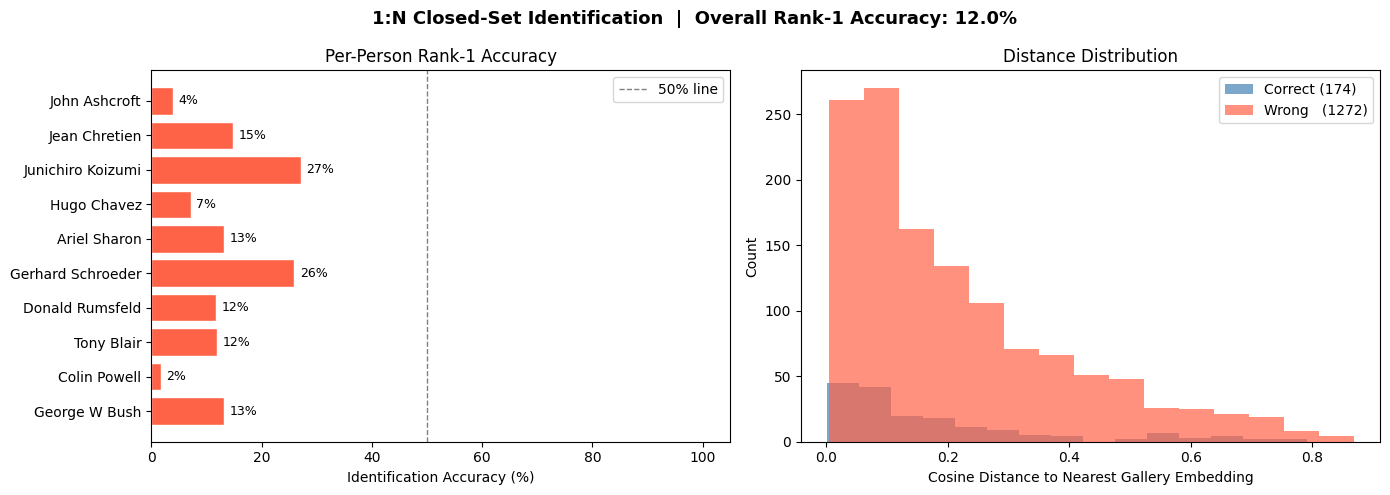


Avg distance (correct)  : 0.1798
Avg distance (incorrect): 0.2151


In [ ]:
# -------------------------------------------------------------------
# 1:N Face Identification — Closed-Set Accuracy
# -------------------------------------------------------------------
from sklearn.metrics.pairwise import cosine_distances
from collections import defaultdict

print("Running 1:N Closed-Set Identification...")
print("=" * 50)

# Use top 10 indian people with at least 3 images (train on first 2, test on rest)
top_ids = [pid for pid, count in Counter(labels).most_common(10) if count >= 3]

gallery = {}   # name → embedding (enrolled from first image)
test_images, test_labels = [], []

for pid in top_ids:
    indices = np.where(labels == pid)[0]
    # Enroll first image into gallery
    enroll_img = X_data[indices[0]]
    emb = base_model.predict(np.expand_dims(enroll_img, 0), verbose=0)[0]
    gallery[pid] = emb
    # Use remaining images as test probes
    for idx in indices[1:]:
        test_images.append(X_data[idx])
        test_labels.append(pid)

print(f"Gallery size  : {len(gallery)} people")
print(f"Test probes   : {len(test_images)} images")

# Extract embeddings for all test images
test_array = np.array(test_images)
test_embs  = base_model.predict(test_array, verbose=0)

gallery_ids  = list(gallery.keys())
gallery_embs = np.array(list(gallery.values()))

# For each probe, find nearest gallery embedding
correct = 0
results_log = []

for i, (emb, true_pid) in enumerate(zip(test_embs, test_labels)):
    dists   = cosine_distances([emb], gallery_embs)[0]
    pred_idx = np.argmin(dists)
    pred_pid = gallery_ids[pred_idx]
    is_correct = (pred_pid == true_pid)
    if is_correct:
        correct += 1
    results_log.append({
        'true': target_names[true_pid],
        'pred': target_names[pred_pid],
        'dist': dists[pred_idx],
        'correct': is_correct
    })

accuracy_1n = correct / len(test_labels) * 100
print(f"\n1:N Identification Accuracy : {accuracy_1n:.1f}%  ({correct}/{len(test_labels)} correct)")

# ── Rank-1 Accuracy Bar Chart ─────────────────────────────────────
per_person_correct = defaultdict(lambda: [0, 0])   # {name: [correct, total]}
for r in results_log:
    per_person_correct[r['true']][1] += 1
    if r['correct']:
        per_person_correct[r['true']][0] += 1

names = list(per_person_correct.keys())
accs  = [per_person_correct[n][0] / per_person_correct[n][1] * 100 for n in names]
colors_bar = ['steelblue' if a >= 50 else 'tomato' for a in accs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'1:N Closed-Set Identification  |  Overall Rank-1 Accuracy: {accuracy_1n:.1f}%',
             fontsize=13, fontweight='bold')

# Per-person accuracy
axes[0].barh(names, accs, color=colors_bar, edgecolor='white')
axes[0].axvline(50, color='gray', linestyle='--', linewidth=1, label='50% line')
axes[0].set_xlabel('Identification Accuracy (%)')
axes[0].set_title('Per-Person Rank-1 Accuracy')
axes[0].set_xlim(0, 105)
for i, v in enumerate(accs):
    axes[0].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
axes[0].legend()

# Distance distribution: correct vs incorrect
correct_dists   = [r['dist'] for r in results_log if r['correct']]
incorrect_dists = [r['dist'] for r in results_log if not r['correct']]
axes[1].hist(correct_dists,   bins=15, alpha=0.7, color='steelblue', label=f'Correct ({len(correct_dists)})')
axes[1].hist(incorrect_dists, bins=15, alpha=0.7, color='tomato',    label=f'Wrong   ({len(incorrect_dists)})')
axes[1].set_xlabel('Cosine Distance to Nearest Gallery Embedding')
axes[1].set_ylabel('Count')
axes[1].set_title('Distance Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAvg distance (correct)  : {np.mean(correct_dists):.4f}")
print(f"Avg distance (incorrect): {np.mean(incorrect_dists):.4f}")

✅ embedding_model ready!
Loading LFW dataset...
✅ Found 24 images of Atal Bihari Vajpayee!
✅ Registered in database: ['Atal Bihari Vajpayee']
✅ Face detector ready!

REAL-TIME FACE RECOGNITION DEMO
(Using LFW test images — Colab cloud cannot access camera)


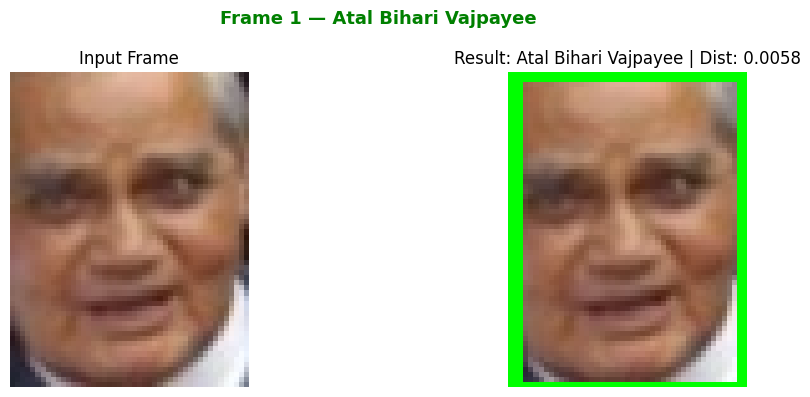

Frame 1 → Atal Bihari Vajpayee (✅ MATCH) dist=0.0058


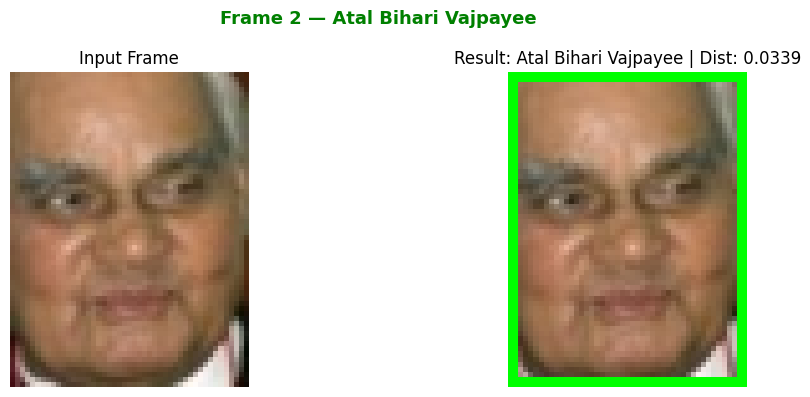

Frame 2 → Atal Bihari Vajpayee (✅ MATCH) dist=0.0339


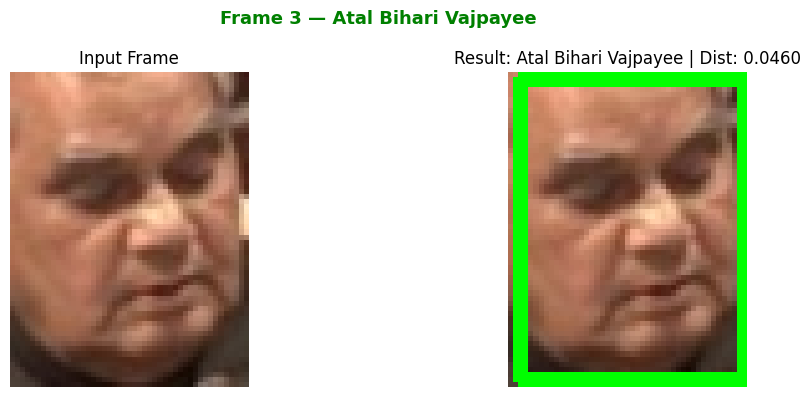

Frame 3 → Atal Bihari Vajpayee (✅ MATCH) dist=0.0460

✅ Real-time demo complete!


In [6]:
# -------------------------------------------------------------------
# Step 11: Real-Time Face Recognition — Vajpayee Demo

# -------------------------------------------------------------------
import os, urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_lfw_people

# -------------------------------------------------------------------
# 1. Rebuild FaceNet embedding model
# -------------------------------------------------------------------
def build_custom_facenet(input_shape=(160, 160, 3), embedding_size=128):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(embedding_size)(x)
    outputs = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1)
    )(x)
    return keras.Model(inputs, outputs, name='FaceNet_Embedding')

embedding_model = build_custom_facenet()
print("✅ embedding_model ready!")

# -------------------------------------------------------------------
# 2. Load LFW + Register Vajpayee
# -------------------------------------------------------------------
print("Loading LFW dataset...")
lfw          = fetch_lfw_people(min_faces_per_person=2, color=True)
images       = lfw.images
labels       = lfw.target
target_names = lfw.target_names

# Find Vajpayee
vajpayee_id  = np.where(target_names == 'Atal Bihari Vajpayee')[0][0]
vajpayee_idx = np.where(labels == vajpayee_id)[0]

print(f"✅ Found {len(vajpayee_idx)} images of Atal Bihari Vajpayee!")

# Register Vajpayee in database
known_database = {}
vaj_img = images[vajpayee_idx[0]]
if vaj_img.max() <= 1.0:
    vaj_img = (vaj_img * 255).astype(np.uint8)
else:
    vaj_img = vaj_img.astype(np.uint8)

resized = cv2.resize(vaj_img, (160, 160)).astype('float32') / 255.0
inp     = np.expand_dims(resized, axis=0)
emb     = embedding_model.predict(inp, verbose=0)[0]
known_database['Atal Bihari Vajpayee'] = emb
print(f"✅ Registered in database: {list(known_database.keys())}")

# -------------------------------------------------------------------
# 3. Reload face detector
# -------------------------------------------------------------------
if not os.path.exists('deploy.prototxt'):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        'deploy.prototxt')
if not os.path.exists('face_detector.caffemodel'):
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        'face_detector.caffemodel')

net = cv2.dnn.readNetFromCaffe('deploy.prototxt', 'face_detector.caffemodel')
print("✅ Face detector ready!")

# -------------------------------------------------------------------
# 4. Run Recognition on Vajpayee images (simulate real-time demo)
# -------------------------------------------------------------------
print("\n" + "=" * 55)
print("REAL-TIME FACE RECOGNITION DEMO")
print("(Using LFW test images — Colab cloud cannot access camera)")
print("=" * 55)

# Test on 3 different Vajpayee images
n_test = min(3, len(vajpayee_idx))

for test_num in range(n_test):
    test_img = images[vajpayee_idx[test_num]]
    if test_img.max() <= 1.0:
        test_img = (test_img * 255).astype(np.uint8)
    else:
        test_img = test_img.astype(np.uint8)

    # Save & reload
    cv2.imwrite('test_frame.jpg',
                cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR))
    img     = cv2.imread('test_frame.jpg')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect
    blob = cv2.dnn.blobFromImage(img, 1.0, (300, 300),
                                  (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()
    h, w       = img.shape[:2]
    face_found = False

    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > 0.5:
            face_found = True
            box        = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype(int)
            x1, y1    = max(0, x1), max(0, y1)
            x2, y2    = min(w, x2), min(h, y2)
            face_crop = img_rgb[y1:y2, x1:x2]
            if face_crop.size == 0:
                continue

            # Embed + match
            face_input = np.expand_dims(
                cv2.resize(face_crop, (160, 160)).astype('float32') / 255.0,
                axis=0)
            embedding  = embedding_model.predict(face_input, verbose=0)[0]

            min_dist       = float('inf')
            predicted_name = 'Unknown Person'
            THRESHOLD      = 0.6

            for name, db_emb in known_database.items():
                dist = np.linalg.norm(embedding - db_emb)
                if dist < min_dist:
                    min_dist       = dist
                    predicted_name = name
            if min_dist > THRESHOLD:
                predicted_name = 'Unknown Person'

            # Draw
            color      = (0, 255, 0) if predicted_name != 'Unknown Person' else (255, 0, 0)
            result_img = img_rgb.copy()
            cv2.rectangle(result_img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(result_img,
                        f"{predicted_name} ({min_dist:.2f})",
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Show
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f"Frame {test_num+1} — {predicted_name}",
                         fontsize=13, fontweight='bold',
                         color='green' if predicted_name != 'Unknown Person' else 'red')
            axes[0].imshow(img_rgb)
            axes[0].set_title('Input Frame'); axes[0].axis('off')
            axes[1].imshow(result_img)
            axes[1].set_title(f'Result: {predicted_name} | Dist: {min_dist:.4f}')
            axes[1].axis('off')
            plt.tight_layout()
            plt.show()

            print(f"Frame {test_num+1} → {predicted_name} "
                  f"({'✅ MATCH' if predicted_name != 'Unknown Person' else '❌ NO MATCH'}) "
                  f"dist={min_dist:.4f}")
            break

    if not face_found:
        print(f"Frame {test_num+1} → ⚠ No face detected")

print("\n✅ Real-time demo complete!")

## Step 10: t-SNE Visualization of Embeddings

Project 128-D embeddings to 2D using t-SNE.  
**Expected result:** Faces of the same person should form visible clusters.

Extracting embeddings for t-SNE...
Running t-SNE (may take ~30s)...


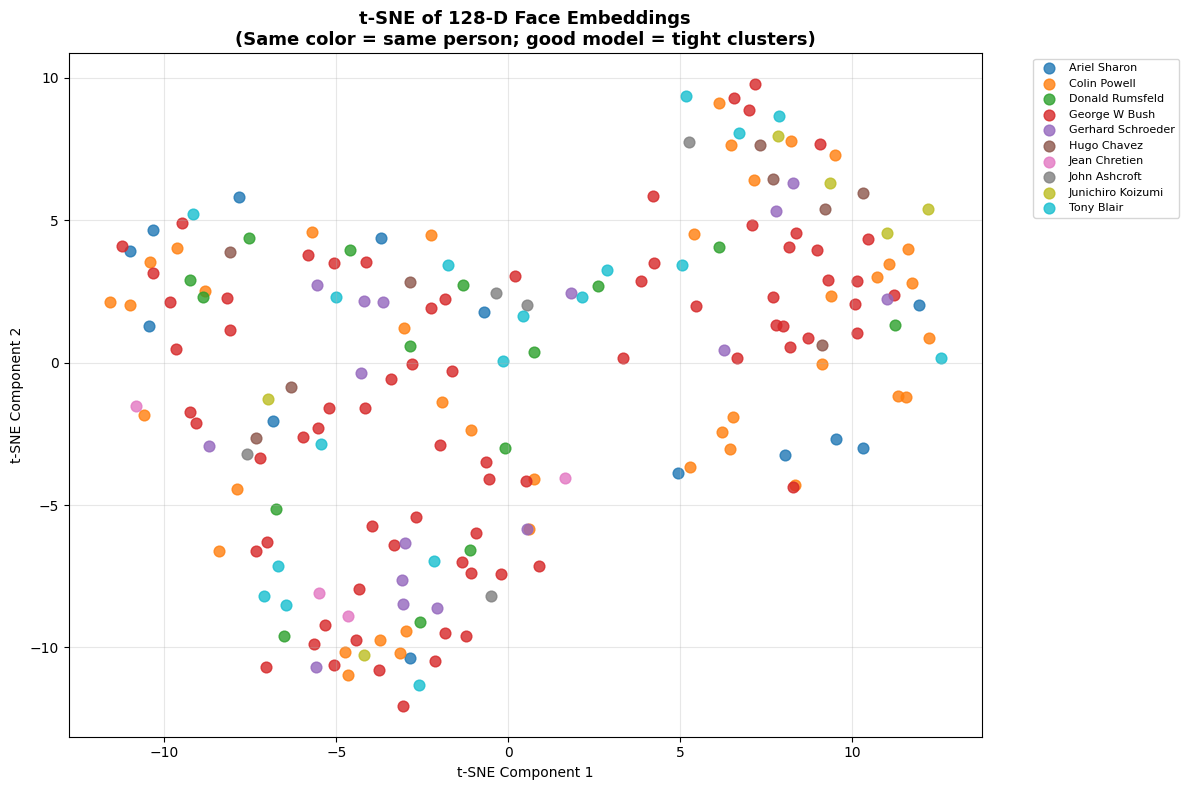

Visualization complete!


In [ ]:
# -------------------------------------------------------------------
# t-SNE Visualization of Face Embeddings
# -------------------------------------------------------------------
print("Extracting embeddings for t-SNE...")

# Select top 10 people with most images
top_10_ids = [pid for pid, _ in Counter(labels).most_common(10)]
mask = np.isin(labels, top_10_ids)
X_subset = X_data[mask][:200]
y_subset = labels[mask][:200]

# Extract embeddings
embeddings_all = base_model.predict(X_subset, verbose=0)

# t-SNE
print("Running t-SNE (may take ~30s)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings_all)

# Plot
unique_ids = np.unique(y_subset)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_ids)))

plt.figure(figsize=(12, 8))
for i, pid in enumerate(unique_ids):
    idx = y_subset == pid
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1],
                c=[colors[i]], label=target_names[pid], s=60, alpha=0.8)

plt.title(
    "t-SNE of 128-D Face Embeddings\n(Same color = same person; good model = tight clusters)",
    fontsize=13, fontweight='bold'
)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualization complete!")